Training with SGD...
  Final loss: 0.000010, weight: 1.9979, bias: 0.0048
Training with Adagrad...
  Final loss: 28.278568, weight: 0.2130, bias: 0.8741
Training with Adam...
  Final loss: 1.983864, weight: 1.0325, bias: 2.1261
Training with Adamax...
  Final loss: 1.181661, weight: 1.2512, bias: 1.6381
Training with ASGD...
  Final loss: 0.000108, weight: 1.9931, bias: 0.0157
Training with LBFGS...
  Final loss: 0.000000, weight: 2.0000, bias: 0.0000
Training with RMSprop...
  Final loss: 0.016933, weight: 1.9118, bias: 0.1956
Training with Rprop...
  Final loss: 0.000000, weight: 2.0000, bias: 0.0000


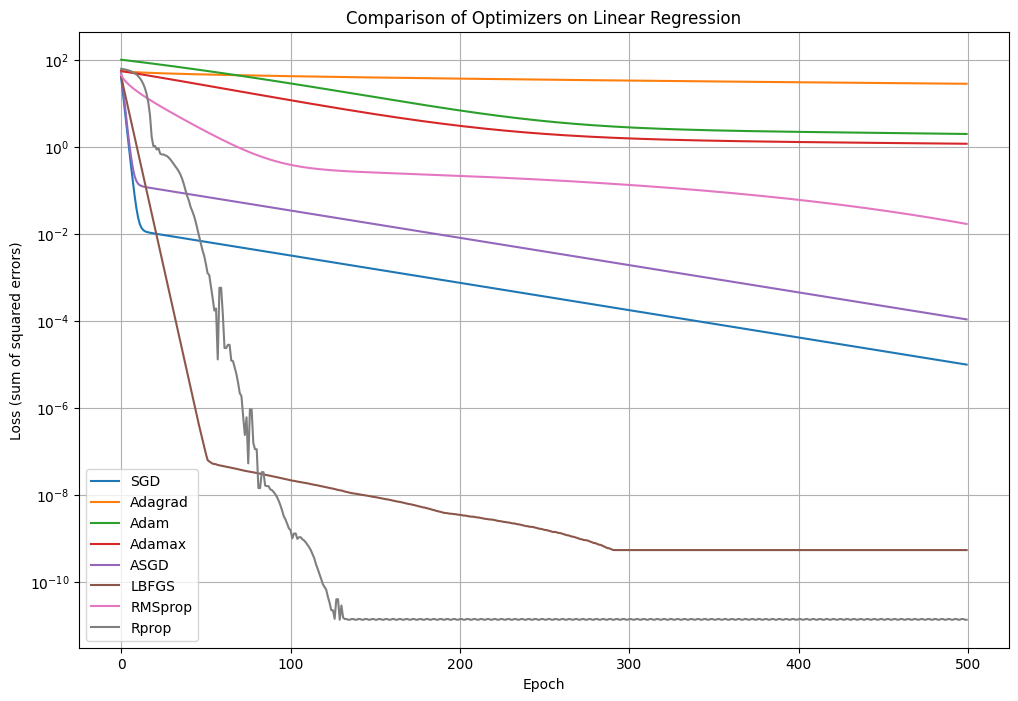

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 设置随机种子，保证可重复性
torch.manual_seed(1)

# 1. 准备数据集（与 PDF 中一致）
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[2.0], [4.0], [6.0]])

# 2. 定义模型类（继承 nn.Module）
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(1, 1)   # 输入特征1，输出特征1

    def forward(self, x):
        return self.linear(x)

# 3. 损失函数：采用与 PDF 相同的 MSELoss，reduction='sum'（原代码 size_average=False）
criterion = nn.MSELoss(reduction='sum')

# 4. 定义要测试的优化器列表（包含名称和构造器）
optimizers_config = [
    ('SGD', lambda params: optim.SGD(params, lr=0.01)),
    ('Adagrad', lambda params: optim.Adagrad(params, lr=0.01)),
    ('Adam', lambda params: optim.Adam(params, lr=0.01)),
    ('Adamax', lambda params: optim.Adamax(params, lr=0.01)),
    ('ASGD', lambda params: optim.ASGD(params, lr=0.01)),
    ('LBFGS', lambda params: optim.LBFGS(params, lr=0.01)),
    ('RMSprop', lambda params: optim.RMSprop(params, lr=0.01)),
    ('Rprop', lambda params: optim.Rprop(params, lr=0.01)),
]

# 训练轮数
num_epochs = 500   # 可根据需要调整，LBFGS 收敛较快，但为统一使用500

# 用于存储每个优化器的损失历史
loss_history = {}

# 对每个优化器进行训练
for name, opt_constructor in optimizers_config:
    print(f"Training with {name}...")
    # 重新初始化模型（确保每个优化器从相同的初始参数开始）
    model = LinearModel()
    optimizer = opt_constructor(model.parameters())
    
    losses = []
    
    for epoch in range(num_epochs):
        # 前向传播
        y_pred = model(x_data)
        loss = criterion(y_pred, y_data)
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        
        # LBFGS 需要特殊的 step 方式（传入闭包）
        if name == 'LBFGS':
            def closure():
                optimizer.zero_grad()
                y_pred = model(x_data)
                loss = criterion(y_pred, y_data)
                loss.backward()
                return loss
            optimizer.step(closure)
        else:
            optimizer.step()
    
    loss_history[name] = losses
    print(f"  Final loss: {losses[-1]:.6f}, weight: {model.linear.weight.item():.4f}, bias: {model.linear.bias.item():.4f}")

# 5. 绘制损失曲线
plt.figure(figsize=(12, 8))
for name, losses in loss_history.items():
    plt.plot(range(num_epochs), losses, label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss (sum of squared errors)')
plt.title('Comparison of Optimizers on Linear Regression')
plt.legend()
plt.grid(True)
plt.yscale('log')   # 对数坐标更清晰
plt.show() 